In [1]:
import snowflake.connector
import pandas as pd
import duckdb
import re
import matplotlib.pyplot as plt


### Hardcoded for a day in NY


In [4]:
# Connect to Snowflake
conn = snowflake.connector.connect(
    user='NLEBLANC',
    password='MagicTheGathering2025!',
    account='hxztlyj-mag',
    warehouse='XSMALL_COMPUTE_WAREHOUSE',
    # database='LZ',
    # schema='DAYZERINPUT_MDBS_ANALYSIS'
)

# Create a cursor
cur = conn.cursor()

# -------------------------------------
# Insert your long SQL query here
# -------------------------------------
query = """
-- SET pool_id=1;

-- Voici la prochaine étape de la query propre ci-dessus
WITH STAGING as 
(
    SELECT intervalid,itemid,constraintid,SF, SIMULATIONDATE
    -- select top 10 *
    FROM LZ.DAYZER_CSVS.SF 
    WHERE scenarioname = 'NYPP_1DA_Default'
    -- and csvdate = '2025-11-25'
    and csvdate = CURRENT_DATE()-2 -- For the day before
    -- csv_date = CURRENT_DATE() -- For the current day
), STAGINGOI AS 
(
    SELECT intervalid,hour
    FROM LZ.DAYZER_CSVS.OUTAGEINTERVALS
    WHERE scenarioname = 'NYPP_1DA_Default'
    -- and csvdate = '2025-11-25'
    and csvdate = CURRENT_DATE()-2 -- For the day before
    -- csv_date = CURRENT_DATE() -- For the current day
), DA_hourly_SF AS
(
    SELECT * FROM STAGING A 
    INNER JOIN STAGINGOI B  
    on A.intervalid = B.intervalid
    -- where A.Constraintid = 310821;
    -- where A.Constraintid = 20014)
), DA_hourly_SP AS
(
    select sp.date, sp.he, sp.peakid, sp.cid_mag, min(sp.cid_ces) as MIN_CES_CID, sp.constraintname, sp.MAG_REF_PACKAGEVERSION__ID, sp.shadowprice
    from MAGSNOWFLAKE.DAYZER.prod_da_constraints_mapped as sp
    WHERE MAG_REF_POOL__ID = $pool_id
        and mag_ref_packageversion__id=228
        -- and mag_ref_packageversion__id=253
        -- and date = '2025-11-25'
        -- and date = CURRENT_DATE()-1 -- For the day before
        and date = CURRENT_DATE()-2 -- For the current day
    group by all
    order by cid_mag
)
, DA_hourly_Congestion AS
(
    select sp.date, sp.he, sp.peakid, sp.cid_mag, sp.MIN_CES_CID, sp.constraintname, sp.shadowprice, sf.sf, sf.itemid, sp.MAG_REF_PACKAGEVERSION__ID, sf.SIMULATIONDATE, (sp.shadowprice*sf.sf) as ConstraintCongestion
    from DA_hourly_SP as sp
    join DA_hourly_SF as sf
    on sp.MIN_CES_CID=sf.constraintid
        and sp.he=sf.hour
        -- and sp.cid_ces=sf.constraintid
    order by sf.constraintid
    -- ;
)

-- select *
-- from DA_hourly_Congestion con
-- order by itemid
-- ;

-- select top 10 *
-- from DA_hourly_SF
-- ;


-- -- insert into MAGSNOWFLAKE.DAYZER.NODES_RESULTS_HOURLY
-- (
--     HEDATE, DATE, HOUR, PEAKID, MAG_REF_POOL__ID, MAGMARKETNAME, NODEMAPPING_MAG_REF__ID, NODEMAPPING_MAG_REF__NAME, MAG_REF_SCENARIO_INFO__ID, SCENARIONAME, SCENARIOROUND, 
--     CONGESTION, SIMULATIONDATE, TIMESTAMPMAG, MAG_REF_SCENARIOTYPE__ID, SCENARIOTYPE, NODEMAPPING_DAYZER_REF__ID, MAG_REF_PACKAGEVERSION__ID, MDBNAME, MAG_REF_PRODUCT__ID, 
--     PRODUCTNAME, ISPRODUCTION, TYPE, UNIQUEKEY
-- )
, DA_HOURLY_NODALCONGESTION AS
(
SELECT
    TIMESTAMP_FROM_PARTS(con.date, TIME_FROM_PARTS(con.he, 0, 0)) AS HEDATE,
    con.date                                     AS DATE,
    con.he                                       AS HOUR,
    con.peakid                                   AS PEAKID,
    1                                            AS MAG_REF_POOL__ID,
    'NY'                                         AS MAGMARKETNAME,
    node.ny_nodemapping_mag_ref__id             AS NODEMAPPING_MAG_REF__ID,
    node.ny_nodemapping_mag_ref__name           AS NODEMAPPING_MAG_REF__NAME,
    522932                                       AS MAG_REF_SCENARIO_INFO__ID,
    'NYPP_1DA_BCCongestionMAG'                   AS SCENARIONAME,
    1                                            AS SCENARIOROUND,
    sum(con.ConstraintCongestion)                               AS CONGESTION,
    con.simulationdate                           AS SIMULATIONDATE,
    GETDATE()                                    AS TIMESTAMPMAG,
    467                                      AS MAG_REF_SCENARIOTYPE__ID,
    '1DA_BCCongestion'                           AS SCENARIOTYPE,
    con.itemid                                   AS NODEMAPPING_DAYZER_REF__ID,
    con.MAG_REF_PACKAGEVERSION__ID                                         AS MAG_REF_PACKAGEVERSION__ID,
    'MdbName'                                    AS MDBNAME,
    2                                            AS MAG_REF_PRODUCT__ID,
    'DailyVirtual'                               AS PRODUCTNAME,
    0                                            AS ISPRODUCTION,
    'Analysis'                                   AS TYPE,
    'UniqueKey'                                  AS UNIQUEKEY
FROM DA_hourly_Congestion con
JOIN MAGSQLSERVER.DAYZERMAG.ny_nodemapping_dayzermag_ref__archive node
    ON con.itemid = node.ny_nodemapping_dayzer_ref__id
    and con.MAG_REF_PACKAGEVERSION__ID=node.MAG_REF_PACKAGEVERSION__ID
-- where con.itemid=13283
-- where con.itemid=51
group by ALL
-- hour, node.MAG_REF_PACKAGEVERSION__ID
-- ;
-- values
-- (
--     TIMESTAMP_FROM_PARTS(con.date, con.he), con.date, con.he, con.peakid, 1, 'NY', node.ny_nodemapping_mag_ref__id, node.ny_nomapping_mag_ref__name, 522932, 'NYPP_1DA_BCCongestionMAG',1,
--     con.congestion, con.simulationdate,GETDATE(), 467, '1DA_BCCongestion', con.itemid, 228, 'MdbName', 2 
--     'DailyVirtual', 0, 'Analysis', 'UniqueKey'
-- )
-- ;
), cube_BCCong AS
(
    SELECT date, peakid, nodemapping_mag_ref__id, scenarioname, lmp, energy, congestion, losses
    -- select top 10 *
    FROM magsnowflake.dayzer_cubes.nodes_results_daily 
    where scenarioname = 'NYPP_1DA_BCCongestion'
        -- and date = '2025-11-30'
        -- and date = CURRENT_DATE() - 2
        and date >= CURRENT_DATE() - 2
        AND date <  CURRENT_DATE() - 1
        order by NODEMAPPING_MAG_REF__ID
), CongDAM AS 
(
    SELECT id, date(date) as date,  SUM(DAM_MCC) DAM_MCC
    -- SELECT id, date, date(date),  DAM_MCC
        FROM MAGSQLSERVER.ALEXANDRIA.NYNODESHOURLY
        WHERE date(date) = CURRENT_DATE()-2
        -- where date >= CURRENT_DATE() - 2
        --     AND date <  CURRENT_DATE() - 1
    group by all
    order by id

    -- SELECT id, date, DAM_LMP, DAM_MCC, DAM_MCL
    -- -- select top 100000 *
    -- FROM MAGSQLSERVER.ALEXANDRIA.NYNODESHOURLY 
    -- -- WHERE date = '2025-11-30'
    -- WHERE date >= CURRENT_DATE() - 2
    --     AND date <  CURRENT_DATE() - 1
    -- order by id

    -- select top 1000 * from MAGSQLSERVER.ALEXANDRIA.NYNODESHOURLY
    -- order by date desc;
        -- and date = CURRENT_DATE() -- For the current day
)
, cube_BCCongMAG AS
(
    -- select * from DA_hourly_NodalCongestion
    -- where scenarioname = 'NYPP_1DA_BCCongestionMAG'
    --     -- and date = '2025-11-30'
    --     and date = CURRENT_DATE()-1 -- For the day before
    --     -- and date = CURRENT_DATE() -- For the current day
    select date(date) as date, nodemapping_mag_ref__id, sum(congestion) as dailysum_congestion
    from DA_HOURLY_NODALCONGESTION
    group by all
    order by nodemapping_mag_ref__id
    -- ;
)


-- select top 10 *
-- -- from cube_BCCong
-- -- from CongDAM
-- from cube_BCCongMAG
-- ;
-- select top 10 * from DA_hourly_NodalCongestion
-- where scenarioname = 'NYPP_1DA_BCCongestionMAG'
--     and date = '2025-11-30'
-- ;

select CongDAM.date, CongDAM.id, DAM_MCC, cube_BCCong.congestion as BCCongestion, cube_BCCongMAG.dailysum_congestion as BCCongestionMAG, cube_BCCong.scenarioname
-- cube_BCCongMAG.hour, CongDAM.he, 

-- from MAGSNOWFLAKE.DAYZER.NODES_RESULTS_HOURLY BCCongMAG
from CongDAM
join cube_BCCong
on CongDAM.date=cube_BCCong.date
    and CongDAM.id=cube_BCCong.NODEMAPPING_MAG_REF__ID
join cube_BCCongMAG
on CongDAM.date=cube_BCCongMAG.date
    and CongDAM.id=cube_BCCongMAG.NODEMAPPING_MAG_REF__ID
order by id
-- where scenarioname = 'NYPP_1DA_BCCongestion'
--     and CongDAM.date = '2025-11-26'
--     -- and date = CURRENT_DATE()-1  -- For the day before
--     -- and date = CURRENT_DATE()  -- For the current before
;
"""

# Execute query
cur.execute("SET pool_id = 1;")
cur.execute(query)

# Fetch into DataFrame
results_df = cur.fetch_pandas_all()

# Close
cur.close()
conn.close()

# Display
print(results_df.head(10))


         DATE     ID  DAM_MCC  BCCONGESTION  BCCONGESTIONMAG  \
0  2025-12-08  23512   0.5700      -0.02100        -0.515266   
1  2025-12-08  23513   0.6000      -0.00049        40.613172   
2  2025-12-08  23514   0.0000       0.00000        -0.120535   
3  2025-12-08  23515   0.6000      -0.00049        -0.496830   
4  2025-12-08  23516   0.6000      -0.02216        -0.512557   
5  2025-12-08  23517   0.6000      -0.02713        -0.506618   
6  2025-12-08  23518   0.6000      -0.02216        -0.512557   
7  2025-12-08  23520   0.6000      -0.02100        -0.515266   
8  2025-12-08  23522  79.2500      39.27515        -1.266740   
9  2025-12-08  23523   0.6000      -0.02713        -0.506618   

            SCENARIONAME  
0  NYPP_1DA_BCCongestion  
1  NYPP_1DA_BCCongestion  
2  NYPP_1DA_BCCongestion  
3  NYPP_1DA_BCCongestion  
4  NYPP_1DA_BCCongestion  
5  NYPP_1DA_BCCongestion  
6  NYPP_1DA_BCCongestion  
7  NYPP_1DA_BCCongestion  
8  NYPP_1DA_BCCongestion  
9  NYPP_1DA_BCCongestion 

### Trying to generalize the code


In [ ]:
# Connect to Snowflake
conn = snowflake.connector.connect(
    user='NLEBLANC',
    password='MagicTheGathering2025!',
    account='hxztlyj-mag',
    warehouse='XSMALL_COMPUTE_WAREHOUSE',
    # database='LZ',
    # schema='DAYZERINPUT_MDBS_ANALYSIS'
)

# Create a cursor
cur = conn.cursor()

# -------------------------------------
# Insert your long SQL query here
# -------------------------------------
query = """

-- Voici la prochaine étape de la query propre ci-dessus
WITH STAGING as 
(
    SELECT intervalid,itemid,constraintid,SF, SIMULATIONDATE
    -- select top 10 *
    FROM LZ.DAYZER_CSVS.SF 
    -- WHERE scenarioname = 'NYPP_1DA_Default'
    where SCENARIONAME = $SFScenario
    -- and csvdate = '2025-11-25'
    and csvdate = CURRENT_DATE()-2 -- For the day before
    -- csv_date = CURRENT_DATE() -- For the current day
), STAGINGOI AS 
(
    SELECT intervalid,hour
    FROM LZ.DAYZER_CSVS.OUTAGEINTERVALS
    -- WHERE scenarioname = 'NYPP_1DA_Default'
    where SCENARIONAME = $SFScenario
    -- and csvdate = '2025-11-25'
    and csvdate = CURRENT_DATE()-2 -- For the day before
    -- csv_date = CURRENT_DATE() -- For the current day
), DA_hourly_SF AS
(
    SELECT * FROM STAGING A 
    INNER JOIN STAGINGOI B  
    on A.intervalid = B.intervalid
    -- where A.Constraintid = 310821;
    -- where A.Constraintid = 20014)
), DA_hourly_SP AS
(
    select sp.date, sp.he, sp.peakid, sp.cid_mag, min(sp.cid_ces) as MIN_CES_CID, sp.constraintname, sp.MAG_REF_PACKAGEVERSION__ID, sp.shadowprice
    from MAGSNOWFLAKE.DAYZER.prod_da_constraints_mapped as sp
    WHERE MAG_REF_POOL__ID = $POOLID
        -- and mag_ref_packageversion__id=
        and mag_ref_packageversion__id=$mag_ref_packageversion__id
        -- and mag_ref_packageversion__id=253
        -- and date = '2025-11-25'
        -- and date = CURRENT_DATE()-1 -- For the day before
        and date = CURRENT_DATE()-2 -- For the current day
    group by all
    order by cid_mag
)
, DA_hourly_Congestion AS
(
    select sp.date, sp.he, sp.peakid, sp.cid_mag, sp.MIN_CES_CID, sp.constraintname, sp.shadowprice, sf.sf, sf.itemid, sp.MAG_REF_PACKAGEVERSION__ID, sf.SIMULATIONDATE, (sp.shadowprice*sf.sf) as ConstraintCongestion
    from DA_hourly_SP as sp
    join DA_hourly_SF as sf
    on sp.MIN_CES_CID=sf.constraintid
        and sp.he=sf.hour
        -- and sp.cid_ces=sf.constraintid
    order by sf.constraintid
    -- ;
)

-- select *
-- from DA_hourly_Congestion con
-- order by itemid
-- ;

-- select top 10 *
-- from DA_hourly_SF
-- ;


-- -- insert into MAGSNOWFLAKE.DAYZER.NODES_RESULTS_HOURLY
-- (
--     HEDATE, DATE, HOUR, PEAKID, MAG_REF_POOL__ID, MAGMARKETNAME, NODEMAPPING_MAG_REF__ID, NODEMAPPING_MAG_REF__NAME, MAG_REF_SCENARIO_INFO__ID, SCENARIONAME, SCENARIOROUND, 
--     CONGESTION, SIMULATIONDATE, TIMESTAMPMAG, MAG_REF_SCENARIOTYPE__ID, SCENARIOTYPE, NODEMAPPING_DAYZER_REF__ID, MAG_REF_PACKAGEVERSION__ID, MDBNAME, MAG_REF_PRODUCT__ID, 
--     PRODUCTNAME, ISPRODUCTION, TYPE, UNIQUEKEY
-- )
, DA_HOURLY_NODALCONGESTION AS
(
SELECT
    TIMESTAMP_FROM_PARTS(con.date, TIME_FROM_PARTS(con.he, 0, 0)) AS HEDATE,
    con.date                                     AS DATE,
    con.he                                       AS HOUR,
    con.peakid                                   AS PEAKID,
    $POOLID                                            AS MAG_REF_POOL__ID,
    -- 'NY'                                         AS MAGMARKETNAME,
    $MAGMARKETNAME                               AS MAGMARKETNAME,
    node.ny_nodemapping_mag_ref__id             AS NODEMAPPING_MAG_REF__ID,
    node.ny_nodemapping_mag_ref__name           AS NODEMAPPING_MAG_REF__NAME,
    522932                                       AS MAG_REF_SCENARIO_INFO__ID,
    -- 'NYPP_1DA_BCCongestionMAG'                   AS SCENARIONAME,
    $BCCongestion_scenario                    AS SCENARIONAME,
    1                                            AS SCENARIOROUND,
    sum(con.ConstraintCongestion)                               AS CONGESTION,
    con.simulationdate                           AS SIMULATIONDATE,
    GETDATE()                                    AS TIMESTAMPMAG,
    -- 467                                      AS MAG_REF_SCENARIOTYPE__ID,
    $mag_ref_scenariotype__id                                      AS MAG_REF_SCENARIOTYPE__ID,
    -- '1DA_BCCongestion'                           AS SCENARIOTYPE,
    $SCENARIOTYPE                           AS SCENARIOTYPE,
    con.itemid                                   AS NODEMAPPING_DAYZER_REF__ID,
    con.MAG_REF_PACKAGEVERSION__ID                                         AS MAG_REF_PACKAGEVERSION__ID,
    'MdbName'                                    AS MDBNAME,
    -- 2                                            AS MAG_REF_PRODUCT__ID,
    $PRODUCTID                                            AS MAG_REF_PRODUCT__ID,
    -- 'DailyVirtual'                               AS PRODUCTNAME,
    $PRODUCTNAME                               AS PRODUCTNAME,
    0                                            AS ISPRODUCTION,
    'Analysis'                                   AS TYPE,
    'UniqueKey'                                  AS UNIQUEKEY
FROM DA_hourly_Congestion con
JOIN MAGSQLSERVER.DAYZERMAG.ny_nodemapping_dayzermag_ref__archive node
    ON con.itemid = node.ny_nodemapping_dayzer_ref__id
    and con.MAG_REF_PACKAGEVERSION__ID=node.MAG_REF_PACKAGEVERSION__ID
-- where con.itemid=13283
-- where con.itemid=51
group by ALL
-- hour, node.MAG_REF_PACKAGEVERSION__ID
-- ;
-- values
-- (
--     TIMESTAMP_FROM_PARTS(con.date, con.he), con.date, con.he, con.peakid, 1, 'NY', node.ny_nodemapping_mag_ref__id, node.ny_nomapping_mag_ref__name, 522932, 'NYPP_1DA_BCCongestionMAG',1,
--     con.congestion, con.simulationdate,GETDATE(), 467, '1DA_BCCongestion', con.itemid, 228, 'MdbName', 2 
--     'DailyVirtual', 0, 'Analysis', 'UniqueKey'
-- )
-- ;
), cube_BCCong AS
(
    SELECT date, peakid, nodemapping_mag_ref__id, scenarioname, lmp, energy, congestion, losses
    -- select top 10 *
    FROM magsnowflake.dayzer_cubes.nodes_results_daily 
    where scenarioname = $BCCongestion_scenario
        -- and date = '2025-11-30'
        -- and date = CURRENT_DATE() - 2
        and date >= CURRENT_DATE() - 2
        AND date <  CURRENT_DATE() - 1
        order by NODEMAPPING_MAG_REF__ID
), CongDAM AS 
(
    SELECT id, date(date) as date,  SUM(DAM_MCC) DAM_MCC
    -- SELECT id, date, date(date),  DAM_MCC
        FROM MAGSQLSERVER.ALEXANDRIA.NYNODESHOURLY
        WHERE date(date) = CURRENT_DATE()-2
        -- where date >= CURRENT_DATE() - 2
        --     AND date <  CURRENT_DATE() - 1
    group by all
    order by id

    -- SELECT id, date, DAM_LMP, DAM_MCC, DAM_MCL
    -- -- select top 100000 *
    -- FROM MAGSQLSERVER.ALEXANDRIA.NYNODESHOURLY 
    -- -- WHERE date = '2025-11-30'
    -- WHERE date >= CURRENT_DATE() - 2
    --     AND date <  CURRENT_DATE() - 1
    -- order by id

    -- select top 1000 * from MAGSQLSERVER.ALEXANDRIA.NYNODESHOURLY
    -- order by date desc;
        -- and date = CURRENT_DATE() -- For the current day
)
, cube_BCCongMAG AS
(
    -- select * from DA_hourly_NodalCongestion
    -- where scenarioname = 'NYPP_1DA_BCCongestionMAG'
    --     -- and date = '2025-11-30'
    --     and date = CURRENT_DATE()-1 -- For the day before
    --     -- and date = CURRENT_DATE() -- For the current day
    select date(date) as date, nodemapping_mag_ref__id, sum(congestion) as dailysum_congestion
    from DA_HOURLY_NODALCONGESTION
    group by all
    order by nodemapping_mag_ref__id
    -- ;
)


-- select top 10 *
-- -- from cube_BCCong
-- -- from CongDAM
-- from cube_BCCongMAG
-- ;
-- select top 10 * from DA_hourly_NodalCongestion
-- where scenarioname = 'NYPP_1DA_BCCongestionMAG'
--     and date = '2025-11-30'
-- ;

select CongDAM.date, CongDAM.id, DAM_MCC, cube_BCCong.congestion as BCCongestion, cube_BCCongMAG.dailysum_congestion as BCCongestionMAG, cube_BCCong.scenarioname
-- cube_BCCongMAG.hour, CongDAM.he, 

-- from MAGSNOWFLAKE.DAYZER.NODES_RESULTS_HOURLY BCCongMAG
from CongDAM
join cube_BCCong
on CongDAM.date=cube_BCCong.date
    and CongDAM.id=cube_BCCong.NODEMAPPING_MAG_REF__ID
join cube_BCCongMAG
on CongDAM.date=cube_BCCongMAG.date
    and CongDAM.id=cube_BCCongMAG.NODEMAPPING_MAG_REF__ID
order by id
-- where scenarioname = 'NYPP_1DA_BCCongestion'
--     and CongDAM.date = '2025-11-26'
--     -- and date = CURRENT_DATE()-1  -- For the day before
--     -- and date = CURRENT_DATE()  -- For the current before
;
"""

# Execute query
cur.execute("SET POOLID = 1;")
# cur.execute("SET POOLID = 0;")
cur.execute("SET PRODUCTID = 2;")
cur.execute("SET ScenarioTypeID = 1;")

cur.execute("SET SCENARIOTYPE = '1DA_BCCongestion';")

cur.execute("""
    SET MAGMARKETNAME = (
        select magmarketname
        from magsqlserver.dayzermag.mag_ref_market
        where mag_ref_market__id=$poolid
    );
""")

cur.execute("""
    SET mag_ref_scenariotype__id = (
        select mag_ref_scenariotype__id
        from magsqlserver.dayzermag.mag_ref_scenariotype
        where scenariotype = $SCENARIOTYPE
    );
""")

cur.execute("""
    SET PRODUCTNAME = (
        select productname
        from magsqlserver.dayzermag.MAG_REF_PRODUCT
        where mag_ref_product__id=$productid
    );
""")

cur.execute("""
    SET SFScenario = ( 
    -- SET SFScenarioList = (
    -- SELECT LISTAGG(DISTINCT SCENARIONAME, ',') -- Returns a list of all the scenarios
    SELECT DISTINCT SCENARIONAME -- When we only want the 1DA_Default, not the Daily_1DA_Default
    -- select top 10 *
    FROM MAGSNOWFLAKE.DAYZER.SFR_SCENARIO_TO_BE_CUBED
    WHERE MAG_REF_POOL__ID = $POOLID
      AND MAG_REF_PRODUCT__ID = $PRODUCTID
      AND MAG_REF_SCENARIOTYPE__ID = $ScenarioTypeID
      AND SCENARIONAME NOT ILIKE '%daily%' -- When we only want the 1DA_Default, not the Daily_1DA_Default
);
""")

# We use this one for now (hardcoded)
cur.execute("SET mag_ref_packageversion__id = 238;")

# This is the real one we should use
# cur.execute("""
#     SET mag_ref_packageversion__id = (
#     select max(mag_ref_packageversion__id)
#     from MAGSNOWFLAKE.DAYZER.prod_da_constraints_mapped as sp
#         WHERE MAG_REF_POOL__ID = $POOLID
#             -- and mag_ref_packageversion__id=228
# );
# """)

cur.execute("""
     SET BCCongestion_scenario = (
select distinct scenarioname
FROM magsnowflake.dayzer_cubes.nodes_results_daily 
where scenarioname ilike '%1DA_BCCongestion'
    and mag_ref_pool__id=$poolid
);
""")

cur.execute("SET DateFrom = CURRENT_DATE()-2;")
cur.execute("SET DateTo = CURRENT_DATE()-2;")
cur.execute(query)

# Fetch into DataFrame
results_df = cur.fetch_pandas_all()

# Close
cur.close()
conn.close()

# Display
print(results_df.head(10))


KeyboardInterrupt: 

In [ ]:
# Connect to Snowflake
conn = snowflake.connector.connect(
    user='NLEBLANC',
    password='MagicTheGathering2025!',
    account='hxztlyj-mag',
    warehouse='XSMALL_COMPUTE_WAREHOUSE',
    # database='LZ',
    # schema='DAYZERINPUT_MDBS_ANALYSIS'
)

# Create a cursor
cur = conn.cursor()

# Execute query
cur.execute("SET POOLID = 1;")
# cur.execute("SET POOLID = 0;")
cur.execute("SET PRODUCTID = 2;")
cur.execute("SET ScenarioTypeID = 1;")

cur.execute("SET SCENARIOTYPE = '1DA_BCCongestion';")

cur.execute("""
    SET MAGMARKETNAME = (
        select magmarketname
        from magsqlserver.dayzermag.mag_ref_market
        where mag_ref_market__id=$poolid
    );
""")

cur.execute("""
    SET mag_ref_scenariotype__id = (
        select mag_ref_scenariotype__id
        from magsqlserver.dayzermag.mag_ref_scenariotype
        where scenariotype = $SCENARIOTYPE
    );
""")

cur.execute("""
    SET PRODUCTNAME = (
        select productname
        from magsqlserver.dayzermag.MAG_REF_PRODUCT
        where mag_ref_product__id=$productid
    );
""")

cur.execute("""
    SET SFScenario = ( 
    -- SET SFScenarioList = (
    -- SELECT LISTAGG(DISTINCT SCENARIONAME, ',') -- Returns a list of all the scenarios
    SELECT DISTINCT SCENARIONAME -- When we only want the 1DA_Default, not the Daily_1DA_Default
    -- select top 10 *
    FROM MAGSNOWFLAKE.DAYZER.SFR_SCENARIO_TO_BE_CUBED
    WHERE MAG_REF_POOL__ID = $POOLID
      AND MAG_REF_PRODUCT__ID = $PRODUCTID
      AND MAG_REF_SCENARIOTYPE__ID = $ScenarioTypeID
      AND SCENARIONAME NOT ILIKE '%daily%' -- When we only want the 1DA_Default, not the Daily_1DA_Default
);
""")
cur.execute("""
     SET mag_ref_packageversion__id = (
     select max(mag_ref_packageversion__id)
     from MAGSNOWFLAKE.DAYZER.prod_da_constraints_mapped as sp
         WHERE MAG_REF_POOL__ID = $POOLID
             -- and mag_ref_packageversion__id=228
 );
""")
cur.execute("""
     SET BCCongestion_scenario = (
select distinct scenarioname
FROM magsnowflake.dayzer_cubes.nodes_results_daily 
where scenarioname ilike '%1DA_BCCongestion'
    and mag_ref_pool__id=$poolid
);
""")

cur.execute("SELECT $POOLID, $productid, $scenariotypeid, $SFScenario, $SCENARIOTYPE, $mag_ref_packageversion__id, $MAGMARKETNAME, $mag_ref_scenariotype__id, $PRODUCTNAME, $BCCongestion_scenario;")
print("Variable values:", cur.fetchone())

# Close
cur.close()
conn.close()



Variable values: (1, 2, 1, 'NYPP_1DA_Default', 253, 'NY', 'DailyVirtual', 'NYPP_1DA_BCCongestion')


### Rest of the code

In [5]:
results_df = results_df.sort_values(by="ID", ascending=True)
display(results_df)


,DATE,ID,DAM_MCC,BCCONGESTION,BCCONGESTIONMAG,SCENARIONAME
0,2025-12-08,23512,0.5700,-0.02100,-0.515266,NYPP_1DA_BCCongestion
1,2025-12-08,23513,0.6000,-0.00049,40.613172,NYPP_1DA_BCCongestion
2,2025-12-08,23514,0.0000,0.00000,-0.120535,NYPP_1DA_BCCongestion
3,2025-12-08,23515,0.6000,-0.00049,-0.496830,NYPP_1DA_BCCongestion
4,2025-12-08,23516,0.6000,-0.02216,-0.512557,NYPP_1DA_BCCongestion
...,...,...,...,...,...,...
536,2025-12-08,345032,0.0000,0.00000,-0.063266,NYPP_1DA_BCCongestion
537,2025-12-08,345033,0.0000,0.00000,-0.063908,NYPP_1DA_BCCongestion
538,2025-12-08,345034,0.0000,0.00000,-0.101258,NYPP_1DA_BCCongestion
539,2025-12-08,345035,0.0000,286.57003,-258.240000,NYPP_1DA_BCCongestion


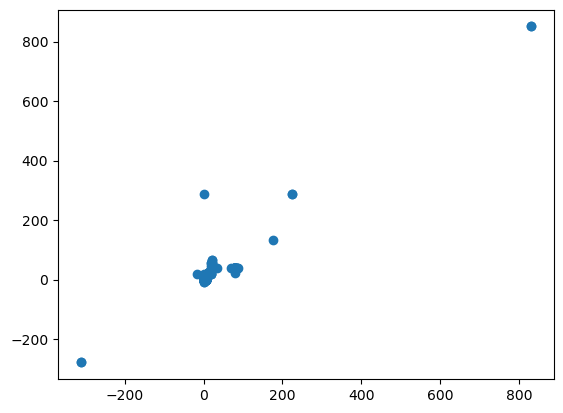

In [10]:
plt.scatter(results_df["DAM_MCC"], results_df["BCCONGESTION"])



In [18]:
import plotly.express as px
import numpy as np

# Convert Decimal → float
results_df["DAM_MCC"] = results_df["DAM_MCC"].astype(float)
results_df["BCCONGESTION"] = results_df["BCCONGESTION"].astype(float)

# Trend line
m, b = np.polyfit(results_df["DAM_MCC"], results_df["BCCONGESTION"], 1)
results_df["trendline"] = m * results_df["DAM_MCC"] + b

fig = px.scatter(
    results_df,
    x="DAM_MCC",
    y="BCCONGESTION",
    hover_name="ID",              # ID displayed on hover
    title="MCC Market vs BCCongestion"
)

fig.add_traces(px.line(
    results_df.sort_values("DAM_MCC"),
    x="DAM_MCC", y="trendline"
).update_traces(line=dict(dash="dash")).data)

fig.show()


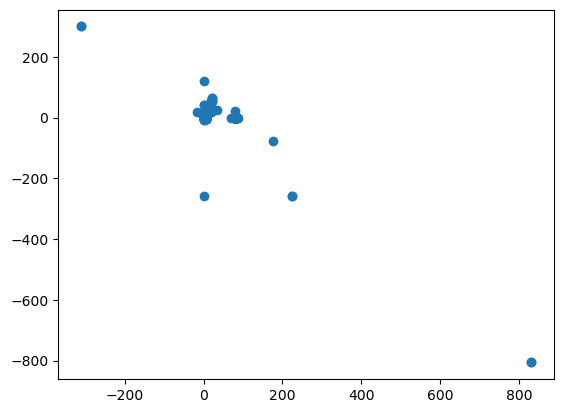

In [7]:
plt.scatter(results_df["DAM_MCC"], results_df["BCCONGESTIONMAG"])



In [17]:
import plotly.express as px
import numpy as np

# Convert Decimal → float
results_df["DAM_MCC"] = results_df["DAM_MCC"].astype(float)
results_df["BCCONGESTIONMAG"] = results_df["BCCONGESTIONMAG"].astype(float)

# Trend line
m, b = np.polyfit(results_df["DAM_MCC"], results_df["BCCONGESTIONMAG"], 1)
results_df["trendline"] = m * results_df["DAM_MCC"] + b

fig = px.scatter(
    results_df,
    x="DAM_MCC",
    y="BCCONGESTIONMAG",
    hover_name="ID",              # ID displayed on hover
    title="MCC Market vs BCCongestionMAG"
)

fig.add_traces(px.line(
    results_df.sort_values("DAM_MCC"),
    x="DAM_MCC", y="trendline"
).update_traces(line=dict(dash="dash")).data)

fig.show()


In [35]:
import pandas as pd
import plotly.express as px

# 1. Aggregate per node
df_grouped = results_df.groupby("ID")[["DAM_MCC", "BCCONGESTION"]].sum().reset_index()

# 2. Create interactive scatter plot
fig = px.scatter(
    df_grouped,
    x="DAM_MCC",
    y="BCCONGESTION",
    hover_name="ID",              # ID displayed on hover
    hover_data={                 # Show x,y values too
        "DAM_MCC": ":.2f",
        "BCCONGESTION": ":.2f"
    },
    title="MCC Market vs MCC Dayzer (BCCONGESTION)"
)

# 3. Add 45-degree line
min_val = min(df_grouped["DAM_MCC"].min(), df_grouped["BCCONGESTION"].min())
max_val = max(df_grouped["DAM_MCC"].max(), df_grouped["BCCONGESTION"].max())

fig.add_shape(
    type="line",
    x0=min_val, y0=min_val,
    x1=max_val, y1=max_val,
    line=dict(dash="dash", width=1)
)

fig.update_layout(
    xaxis_title="MCC Market (DAM_MCC)",
    yaxis_title="MCC Dayzer (BCCONGESTION)",
)

fig.show()


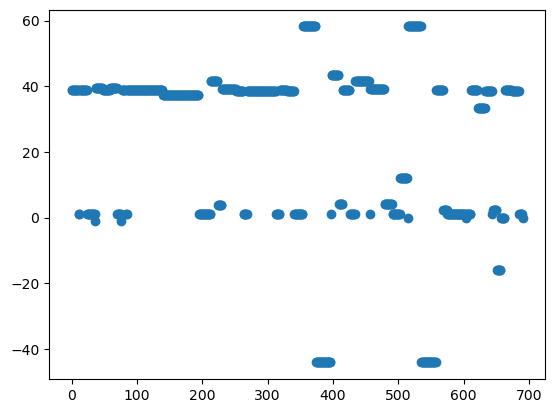

In [28]:
import numpy as np
x = np.arange(len(results_df["DAM_MCC"]))
plt.scatter(x, results_df["DAM_MCC"])